In [1]:
import math
import pandas as pd


DB_PATH = "runs_index.csv"

DB = pd.read_csv(DB_PATH, index_col=0)


PROBLEMS = ['vanderpol', 'davis-skodje']

DB = DB[(DB['seed'] >= 40) & (DB['seed'] <= 49)]

print(DB["problem"].unique())

DB_vdp = DB[DB["problem"] == "vanderpol"]
DB_ds = DB[DB["problem"] == "davis-skodje"]

k_lowest = 3
k_highest = 3


['davis-skodje' 'vanderpol']


In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
FIG_DIR = REPO_ROOT / "analysis" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10.5,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linewidth": 0.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

# Colorblind-safe roles (same categorical slots used in final_vdp_figures.ipynb).
COLOR_STIFF = "#2a78d6"  # StiffNet + collocation + derivmatch
COLOR_GELU = "#eb6834"   # GELU-scaled + shooting + derivmatch

SERIES = [
    dict(model="stiff", pretraining="derivmatch", training="collocation",
         label="StiffNet + Collocation + DerivMatch", color=COLOR_STIFF, marker="o"),
    dict(model="GELU-scaled", pretraining="derivmatch", training="shooting",
         label="GELU-scaled + Shooting + DerivMatch", color=COLOR_GELU, marker="s"),
]

METRIC = "E_trajectory_train"
Y_LABEL = r"$E_{\mathrm{trajectory,\,train}}$ (trimmed mean over seeds)"


def trimmed_mean_by_param(db, metric=METRIC, k_lowest=k_lowest, k_highest=k_highest, series=SERIES):
    """For each (param, model, pretraining, training) group, drop the
    `k_lowest` seeds with the lowest `metric` and the `k_highest` seeds with
    the highest `metric`, then average the remaining seeds.

    Returns a long-format DataFrame with one row per (param, series) giving
    the trimmed mean plus how many seeds were kept/available, so thin groups
    (e.g. GELU-scaled shooting runs that timed out for some seeds) are easy
    to spot.
    """
    db = db.copy()
    db["param"] = pd.to_numeric(db["param"], errors="coerce")

    rows = []
    for s in series:
        mask = ((db["model"] == s["model"]) &
                (db["pretraining"] == s["pretraining"]) &
                (db["training"] == s["training"]))
        sub = db[mask]
        for param, grp in sub.groupby("param"):
            grp = grp.sort_values(metric)
            n = len(grp)
            kept = grp.iloc[k_lowest:n - k_highest] if n > k_lowest + k_highest else grp.iloc[0:0]
            rows.append({
                "param": param,
                "series": s["label"],
                "mean": kept[metric].mean(),
                "n_kept": len(kept),
                "n_total": n,
            })
    return pd.DataFrame(rows)


def plot_stiffness_sweep(db, param_label, title, save_name=None):
    summary = trimmed_mean_by_param(db)
    fig, ax = plt.subplots(figsize=(5.5, 4))
    for s in SERIES:
        row = summary[summary["series"] == s["label"]].sort_values("param")
        ax.plot(row["param"], row["mean"], color=s["color"], marker=s["marker"],
                lw=1.4, ms=5, label=s["label"])
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(param_label)
    ax.set_ylabel(Y_LABEL)
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    if save_name:
        fig.savefig(FIG_DIR / save_name)
    return fig, summary


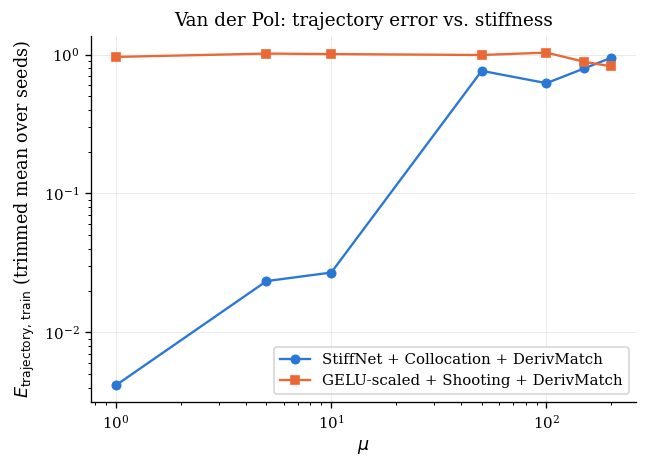

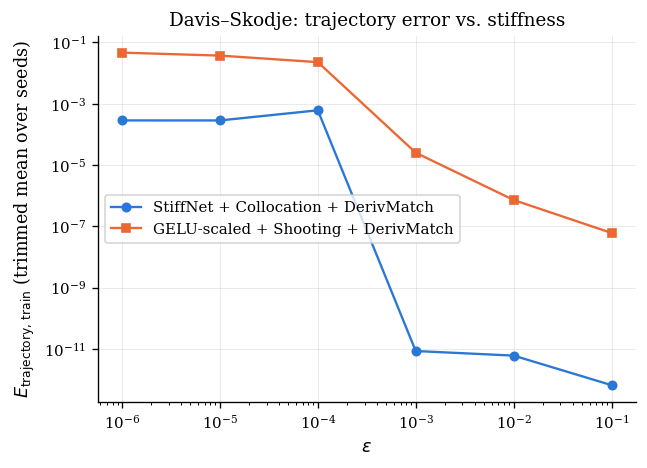

,param,series,mean,n_kept,n_total
7,1.0,GELU-scaled + Shooting + DerivMatch,0.961047,4,10
8,5.0,GELU-scaled + Shooting + DerivMatch,1.015715,1,7
9,10.0,GELU-scaled + Shooting + DerivMatch,1.007015,2,8
10,50.0,GELU-scaled + Shooting + DerivMatch,0.992148,3,9
11,100.0,GELU-scaled + Shooting + DerivMatch,1.031779,3,9
12,150.0,GELU-scaled + Shooting + DerivMatch,0.886319,3,9
13,200.0,GELU-scaled + Shooting + DerivMatch,0.821586,4,10
0,1.0,StiffNet + Collocation + DerivMatch,0.004177,4,10
1,5.0,StiffNet + Collocation + DerivMatch,0.023414,4,10
2,10.0,StiffNet + Collocation + DerivMatch,0.026983,4,10


,param,series,mean,n_kept,n_total
6,0.000001,GELU-scaled + Shooting + DerivMatch,4.650161e-02,4,10
7,0.000010,GELU-scaled + Shooting + DerivMatch,3.717901e-02,4,10
8,0.000100,GELU-scaled + Shooting + DerivMatch,2.277842e-02,4,10
9,0.001000,GELU-scaled + Shooting + DerivMatch,2.532875e-05,4,10
10,0.010000,GELU-scaled + Shooting + DerivMatch,7.277686e-07,4,10
11,0.100000,GELU-scaled + Shooting + DerivMatch,6.118029e-08,4,10
0,0.000001,StiffNet + Collocation + DerivMatch,2.861603e-04,4,10
1,0.000010,StiffNet + Collocation + DerivMatch,2.857130e-04,4,10
2,0.000100,StiffNet + Collocation + DerivMatch,6.120685e-04,4,10
3,0.001000,StiffNet + Collocation + DerivMatch,8.635750e-12,4,10


In [3]:
fig_vdp, summary_vdp = plot_stiffness_sweep(
    DB_vdp, param_label=r"$\mu$",
    title="Van der Pol: trajectory error vs. stiffness",
    save_name="vanderpol_stiffness_sweep.png",
)
fig_ds, summary_ds = plot_stiffness_sweep(
    DB_ds, param_label=r"$\varepsilon$",
    title="Davis–Skodje: trajectory error vs. stiffness",
    save_name="davis_skodje_stiffness_sweep.png",
)
plt.show()

# n_kept < n_total - k_lowest - k_highest would mean a group had too few
# seeds for the requested trim; n_total < 10 flags seeds that never
# produced a completed run (e.g. shooting timeouts) for that param.
display(summary_vdp.sort_values(["series", "param"]))
display(summary_ds.sort_values(["series", "param"]))
